In [1]:
!pip install streamlit gradio
import pandas as pd
sheets = pd.read_excel("/kaggle/input/boroondara2006/Scats Data October 2006.xls", sheet_name=None)

removed_days = sheets["Notes"]["Unnamed: 1"].dropna().to_list()[5:]
removed_days = [int(i) for i in removed_days]
# removed_days

df_info = sheets["Summary Of Data"].loc[2:]
df_info.columns = df_info.iloc[0]
df_info = df_info[1:]
df_info["SCATS Number"] = df_info["SCATS Number"].ffill()

df_info.dropna(axis=1, inplace=True)
df_info = df_info.convert_dtypes().infer_objects()
# df_info.head(15)

df_info_filtered = df_info[df_info["Total"].between(7, 31)]
# df_info_filtered


# imagine having good formatting
df = sheets["Data"]
df.columns = pd.Series(df.loc[0])
df = df.loc[1:]

# remove added time
df.loc[:, 'Date'] = pd.to_datetime(df['Date']).dt.date
df = df.convert_dtypes()

# filter good locations
df = df.loc[df["Location"].isin(df_info_filtered["Location"])]

# add location identifier: SCARS Number + VicRoads Internal
df.loc[:, "Identifier"] = df["SCATS Number"].astype(str) + " - " + df["HF VicRoads Internal"].astype(str)
df.columns = df.columns.str.strip()
df = df.fillna(0)
df.reset_index(drop=True)
df.to_csv("scats.csv")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.6/68.6 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 78.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 444.8/444.8 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 90.6 MB/s eta 0:00:00
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.41.5
    Uninstalling pydantic_core-2.41.5:
      Successfully uninstalled pydantic_core-2.41.5
  Attempting uninstall: pydantic
    Found existing installation: pydantic 2.12.4
    Uninstalling pydantic-2.12.4:
      Successfully uninstalled pydantic-2.12.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.26.4 which is incompat

In [2]:
vcols = [f"V{str(i).zfill(2)}" for i in range(96)]
print(vcols)

['V00', 'V01', 'V02', 'V03', 'V04', 'V05', 'V06', 'V07', 'V08', 'V09', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'V29', 'V30', 'V31', 'V32', 'V33', 'V34', 'V35', 'V36', 'V37', 'V38', 'V39', 'V40', 'V41', 'V42', 'V43', 'V44', 'V45', 'V46', 'V47', 'V48', 'V49', 'V50', 'V51', 'V52', 'V53', 'V54', 'V55', 'V56', 'V57', 'V58', 'V59', 'V60', 'V61', 'V62', 'V63', 'V64', 'V65', 'V66', 'V67', 'V68', 'V69', 'V70', 'V71', 'V72', 'V73', 'V74', 'V75', 'V76', 'V77', 'V78', 'V79', 'V80', 'V81', 'V82', 'V83', 'V84', 'V85', 'V86', 'V87', 'V88', 'V89', 'V90', 'V91', 'V92', 'V93', 'V94', 'V95']


In [3]:
import numpy as np

DAY_LENGTH = 96 # intervals per day
MONTH_LENGTH = 31 # days in oct

d = {}
for id, group in df.groupby(by="Identifier"):
    # identifier + flow
    flow = list(group[vcols].fillna(0).to_numpy().flatten())
    while len(flow) < DAY_LENGTH * MONTH_LENGTH:
        flow.append(0)
    d[id] = flow
    

d = {i: np.array(d[i]) for i in d}
flow = pd.DataFrame(d)
flow



# df_flow = pd.DataFrame(d)

,0970 - 10503,0970 - 16116,0970 - 249,0970 - 5887,2000 - 10505,2000 - 12521,2000 - 2276,2000 - 6246,2200 - 10074,2200 - 12428,...,4324 - 14646,4324 - 16859,4324 - 6621,4812 - 16535,4812 - 4250,4812 - 6302,4821 - -1,4821 - 14527,4821 - 16911,4821 - 6673
0,92,37,86,47,110,94,115,46,25,38,...,32,43,28,58,64,49,0,25,44,86
1,93,30,83,42,93,82,99,41,17,49,...,29,34,25,53,63,54,0,28,50,86
2,90,26,52,31,83,49,94,42,16,32,...,32,35,43,57,83,48,0,21,49,89
3,55,29,58,34,53,64,86,36,21,24,...,15,24,30,43,68,50,0,15,42,74
4,64,14,59,40,58,48,75,26,18,20,...,25,19,19,39,64,31,0,16,31,73
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2971,98,38,79,0,0,0,0,0,17,31,...,39,52,46,0,0,0,0,35,68,87
2972,88,30,71,0,0,0,0,0,24,28,...,23,24,36,0,0,0,0,29,44,75
2973,54,16,55,0,0,0,0,0,17,19,...,28,30,28,0,0,0,0,24,35,63
2974,71,17,45,0,0,0,0,0,14,14,...,22,19,27,0,0,0,0,25,30,51


In [4]:
loc_index = enumerate(flow.columns)
dict(loc_index)

{0: '0970 - 10503',
 1: '0970 - 16116',
 2: '0970 - 249',
 3: '0970 - 5887',
 4: '2000 - 10505',
 5: '2000 - 12521',
 6: '2000 - 2276',
 7: '2000 - 6246',
 8: '2200 - 10074',
 9: '2200 - 12428',
 10: '2200 - 20314',
 11: '2200 - 6819',
 12: '2820 - 14985',
 13: '2820 - 16542',
 14: '2825 - 16628',
 15: '2827 - 10827',
 16: '2827 - 12834',
 17: '2827 - 2578',
 18: '2827 - 588',
 19: '2846 - -1',
 20: '2846 - 16119',
 21: '2846 - 38',
 22: '2846 - 5881',
 23: '3001 - 15725',
 24: '3001 - 16551',
 25: '3001 - 6309',
 26: '3002 - 16538',
 27: '3002 - 16550',
 28: '3002 - 6299',
 29: '3002 - 6310',
 30: '3120 - 16154',
 31: '3120 - 16620',
 32: '3120 - 4175',
 33: '3120 - 6379',
 34: '3122 - 16153',
 35: '3122 - 17054',
 36: '3122 - 5895',
 37: '3126 - 16149',
 38: '3126 - 16485',
 39: '3126 - 5899',
 40: '3127 - 16152',
 41: '3127 - 5896',
 42: '3127 - 6813',
 43: '3180 - 16199',
 44: '3180 - 17052',
 45: '3180 - 5950',
 46: '3662 - 15724',
 47: '3662 - 5482',
 48: '3662 - 6295',
 49: '366

transpose the flow so every row is a time sequence

In [5]:
data = flow.to_numpy().astype(float)
data.shape

(2976, 137)

In [6]:
windows = []

WEEK_LENGTH = DAY_LENGTH * 7  # 1 week
WINDOW_LENGTH = WEEK_LENGTH
for i in range(WINDOW_LENGTH, len(data) + 1):
    windows.append(data[i - WINDOW_LENGTH : i])

windows = np.array(windows)

NUM_WINDOW, _, NUM_LOCATION = windows.shape
for name, val in zip(["Number of windows", "Window Length", "Number of locations"], windows.shape):
    print(f"{name}: {val}")

Number of windows: 2305
Window Length: 672
Number of locations: 137


Train/test split

In [7]:
HORIZON = 24  # assuming hourly data

# Input is all but last HORIZON steps
X = np.array(windows[:, :-HORIZON, :])  # shape: (num_windows, WINDOW_LENGTH - HORIZON, NUM_LOCATIONS)
# Output is the next HORIZON steps
y = np.array(windows[:, -HORIZON:, :])  # shape: (num_windows, HORIZON, NUM_LOCATIONS)

train_size = int(NUM_WINDOW * 0.7)
val_size = int(NUM_WINDOW * 0.15)

X_train = X[:train_size]
X_val   = X[train_size : train_size + val_size]
X_test  = X[train_size + val_size :]

y_train = y[:train_size]
y_val   = y[train_size : train_size + val_size]
y_test  = y[train_size + val_size :]

print("Shapes: ")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

Shapes: 
X_train: (1613, 648, 137)
X_val: (345, 648, 137)
X_test: (347, 648, 137)
y_train: (1613, 24, 137)
y_val: (345, 24, 137)
y_test: (347, 24, 137)


Normalize

In [8]:
from sklearn.preprocessing import StandardScaler

def fit_scaler(A: np.ndarray) -> StandardScaler:
    return StandardScaler().fit(A.reshape(-1, 1))

def normalize(scaler: StandardScaler, A: np.ndarray) -> np.ndarray:
    return scaler.transform(A.reshape(-1, 1)).reshape(A.shape)

# for predictions
def denormalize(scaler: StandardScaler, A: np.ndarray) -> np.ndarray:
    return scaler.inverse_transform(A.reshape(-1, 1)).reshape(A.shape)

# which one should I fit on? X_train?
scaler = fit_scaler(X_train)

X_train_n, X_val_n, X_test_n = normalize(scaler, X_train), normalize(scaler, X_val), normalize(scaler, X_test)
y_train_n, y_val_n, y_test_n = normalize(scaler, y_train), normalize(scaler, y_val), normalize(scaler, y_test)

print("Shapes: ")
print("X_train:", X_train_n.shape)
print("X_val:", X_val_n.shape)
print("X_test:", X_test_n.shape)
print("y_train:", y_train_n.shape)
print("y_val:", y_val_n.shape)
print("y_test:", y_test_n.shape)


Shapes: 
X_train: (1613, 648, 137)
X_val: (345, 648, 137)
X_test: (347, 648, 137)
y_train: (1613, 24, 137)
y_val: (345, 24, 137)
y_test: (347, 24, 137)


Create Repository for Model

In [9]:
import os

d = "model/"
parent_d = "/kaggle/working/"
model_path = os.path.join(parent_d, d)

if not os.path.exists(model_path): 
    os.mkdir(model_path)
    print("Directory created at:", model_path)


Directory created at: /kaggle/working/model/


In [10]:
from keras.models import Sequential
from keras.layers import GRU, LSTM, Input, Dense, RepeatVector, TimeDistributed, Dropout
from keras.models import load_model # assuming you have this import

# Constants from your setup:
# WINDOW_LENGTH = 672
# HORIZON = 24
# NUM_LOCATION = 137 
INPUT_SEQUENCE_LENGTH = WINDOW_LENGTH - HORIZON # 648
OUTPUT_SEQUENCE_LENGTH = HORIZON # 24

def get_seq2seq_lstm(input_seq_len, output_seq_len, num_locations):
    if os.path.exists("/kaggle/working/model/stm.keras"):
        return load_model("/kaggle/working/model/lstm.keras")

    units = 256

    model = Sequential([
        Input(shape=(input_seq_len, num_locations)),

        # Encoder
        LSTM(units, return_sequences=False),
        Dropout(0.2),

        # Repeat context for decoder
        RepeatVector(output_seq_len),

        # Decoder
        LSTM(units, return_sequences=True),
        Dropout(0.1),

        # Output projection
        TimeDistributed(Dense(num_locations))
    ])

    model.compile(
        optimizer="adamw",
        loss="mse",
        metrics=["mae"]
    )
    return model


# Create and Compile the Correct Model
lstm = get_seq2seq_lstm(
    INPUT_SEQUENCE_LENGTH, 
    OUTPUT_SEQUENCE_LENGTH, 
    NUM_LOCATION
)

# Train the Correct Model with the Correct Data Split
# model_seq2seq.fit(X_train_n, y_train_n, epochs=20, batch_size=32) 
# Note: You must use X_train_n and y_train_n, not 'windows' and 'targets'.

print("New Model Summary:")
lstm.summary()

# Add callbacks for better training
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = lstm.fit(
    X_train_n, y_train_n,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_n, y_val_n),
    callbacks=callbacks,
    verbose=1
)

# Print the final loss and validation loss
print(f"Final Training Loss (MSE): {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss (MSE): {history.history['val_loss'][-1]:.4f}")

# Print the final MAE and validation MAE
print(f"Final Training MAE: {history.history['mae'][-1]:.4f}")
print(f"Final Validation MAE: {history.history['val_mae'][-1]:.4f}")

print(history)

d = "loss/"
parent_d = "/kaggle/working/"
loss_path = os.path.join(parent_d, d)

if not os.path.exists(loss_path): 
    os.mkdir(loss_path)
    print("Directory created at:", loss_path)


lstm.save("/kaggle/working/model/lstm.keras")
loss = pd.DataFrame(history.history)
loss.to_csv("/kaggle/working/loss/lstm.csv")

2025-11-24 04:19:46.630414: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763957986.867509      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763957986.934486      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

...

 Trainable params: 963,977 (3.68 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


I0000 00:00:1763958007.890700      74 cuda_dnn.cc:529] Loaded cuDNN version 90300


51/51 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - loss: 0.5751 - mae: 0.5643 - val_loss: 0.3346 - val_mae: 0.3438 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.2095 - mae: 0.3155 - val_loss: 0.2938 - val_mae: 0.3066 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1789 - mae: 0.2854 - val_loss: 0.2389 - val_mae: 0.2719 - learning_rate: 0.0010
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1334 - mae: 0.2479 - val_loss: 0.2351 - val_mae: 0.2938 - learning_rate: 0.0010
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.1395 - mae: 0.2515 - val_loss: 0.2097 - val_mae: 0.2727 - learning_rate: 0.0010
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.1019 - mae: 0.2174 - val_loss: 0.1964 - val_mae: 0.2550 - learning_rate: 0.0010
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0895 - mae: 0.2038 - val_loss: 0.2013 - val_mae: 0.2509 - learning_rate: 0.0010
Epoch 8/100
51/51 

Directory created at: /kaggle/working/images/


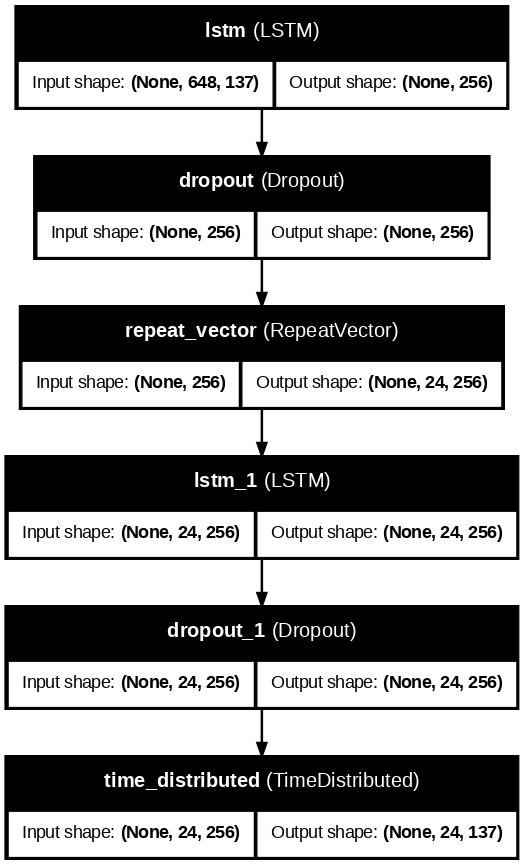

In [11]:
from keras.utils import plot_model

import os

d = "images/"
parent_d = "/kaggle/working/"
image_path = os.path.join(parent_d, d)

if not os.path.exists(image_path): 
    os.mkdir(image_path)
    print("Directory created at:", image_path)

plot_model(
    lstm,
    to_file="/kaggle/working/images/lstm.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=90
)


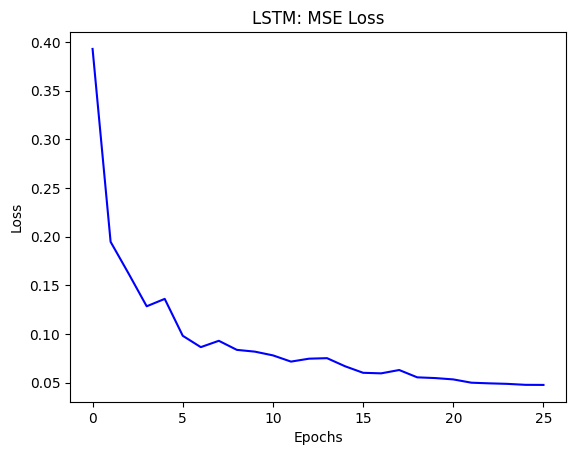

In [12]:
from matplotlib import pyplot as plt

n = len(loss["loss"])
# plt.figure(figsize=(4, 1))
# plt.legend()
plt.title("LSTM: MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(np.arange(n), loss["loss"], "b")

In [13]:
# Make predictions on the normalized test set
# The output shape will be (num_test_windows, HORIZON, NUM_LOCATIONS)
# (347, 24, 137) in your case
y_pred_n = lstm.predict(X_test_n) 

y_pred = denormalize(scaler, y_pred_n)

print(f"Final Denormalized Predictions shape: {y_pred.shape}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step
Final Denormalized Predictions shape: (347, 24, 137)


In [14]:
print(y_pred.shape)
print(y_test.shape)

(347, 24, 137)
(347, 24, 137)


In [15]:
from sklearn import metrics
import math
def eva_regress(y_true: np.ndarray, y_pred: np.ndarray) -> None:
    """Evaluation
    evaluate the predicted resul.

    # Arguments
        y_true: List/ndarray, ture data.
        y_pred: List/ndarray, predicted data.
    """

    y_pred = y_pred.flatten()
    y_true = y_true.flatten()
    # vs = metrics.explained_variance_score(y_true, y_pred)
    # mape = metrics.mean_absolute_percentage_error(y_true, y_pred)
    mae = metrics.mean_absolute_error(y_true, y_pred)
    mse = metrics.mean_squared_error(y_true, y_pred)
    r2 = metrics.r2_score(y_true, y_pred)
    # print('explained_variance_score:%f' % vs)
    # print('mape:%f%%' % mape)
    print('mae:%f' % mae)
    print('mse:%f' % mse)
    print('rmse:%f' % np.sqrt(mse))
    print('r2:%f' % r2)

print("LSTM predictions:")
print()
print("Normalized:")
eva_regress(y_test_n, y_pred_n)

print()
print("Denomalized:")
eva_regress(y_test, y_pred)
print()


LSTM predictions:

Normalized:
mae:0.382626
mse:0.473776
rmse:0.688314
r2:0.482495

Denomalized:
mae:33.562143
mse:3645.221438
rmse:60.375669
r2:0.482495



In [16]:
from keras.models import Sequential
from keras.layers import GRU, LSTM, Input, Dense, RepeatVector, TimeDistributed, Dropout
from keras.models import load_model # assuming you have this import

# Constants from your setup:
# WINDOW_LENGTH = 672
# HORIZON = 24
# NUM_LOCATION = 137 
INPUT_SEQUENCE_LENGTH = WINDOW_LENGTH - HORIZON # 648
OUTPUT_SEQUENCE_LENGTH = HORIZON # 24

def get_seq2seq_gru(input_seq_len: int, output_seq_len: int, num_locations: int):
    if os.path.exists("/kaggle/working/model/gru.keras"):
        return load_model("/kaggle/working/model/gru.keras")

    units = 256

    model = Sequential([
        Input(shape=(input_seq_len, num_locations)),

        # Encoder
        GRU(units, return_sequences=False),
        Dropout(0.2),

        # Repeat context for decoder
        RepeatVector(output_seq_len),

        # Decoder
        GRU(units, return_sequences=True),
        Dropout(0.1),

        # Output projection
        TimeDistributed(Dense(num_locations))
    ])

    model.compile(
        optimizer="adamw",
        loss="mse",
        metrics=["mae"]
    )
    return model


# Create and Compile the Correct Model
gru = get_seq2seq_gru(
    INPUT_SEQUENCE_LENGTH, 
    OUTPUT_SEQUENCE_LENGTH, 
    NUM_LOCATION
)

# Train the Correct Model with the Correct Data Split
# model_seq2seq.fit(X_train_n, y_train_n, epochs=20, batch_size=32) 
# Note: You must use X_train_n and y_train_n, not 'windows' and 'targets'.

print("New Model Summary:")
gru.summary()

# Add callbacks for better training
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True),
    ReduceLROnPlateau(patience=5, factor=0.5)
]

history = gru.fit(
    X_train_n, y_train_n,
    epochs=100,
    batch_size=32,
    validation_data=(X_val_n, y_val_n),
    callbacks=callbacks,
    verbose=1
)

# Print the final loss and validation loss
print(f"Final Training Loss (MSE): {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss (MSE): {history.history['val_loss'][-1]:.4f}")

# Print the final MAE and validation MAE
print(f"Final Training MAE: {history.history['mae'][-1]:.4f}")
print(f"Final Validation MAE: {history.history['val_mae'][-1]:.4f}")

print(history)

d = "loss/"
parent_d = "/kaggle/working/"
loss_path = os.path.join(parent_d, d)

if not os.path.exists(loss_path): 
    os.mkdir(loss_path)
    print("Directory created at:", loss_path)


lstm.save("/kaggle/working/model/gru.keras")
loss = pd.DataFrame(history.history)
loss.to_csv("/kaggle/working/loss/gru.csv")

New Model Summary:


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 256)            │       303,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 24, 256)        │       394,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 24, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 24, 137)        │        35,209 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 733,321 (2.80 MB)

 Trainable params: 733,321 (2.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 6s 61ms/step - loss: 0.6363 - mae: 0.6012 - val_loss: 0.3525 - val_mae: 0.3874 - learning_rate: 0.0010
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.2405 - mae: 0.3504 - val_loss: 0.2924 - val_mae: 0.3493 - learning_rate: 0.0010
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1900 - mae: 0.3073 - val_loss: 0.2506 - val_mae: 0.3184 - learning_rate: 0.0010
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1675 - mae: 0.2900 - val_loss: 0.2070 - val_mae: 0.2777 - learning_rate: 0.0010
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1334 - mae: 0.2579 - val_loss: 0.1983 - val_mae: 0.2685 - learning_rate: 0.0010
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1294 - mae: 0.2507 - val_loss: 0.3178 - val_mae: 0.3295 - learning_rate: 0.0010
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.1455 - mae: 0.2602 - val_loss: 0.1831 - val_mae: 0.2542 - learning_rate: 0.0010
Epoch 

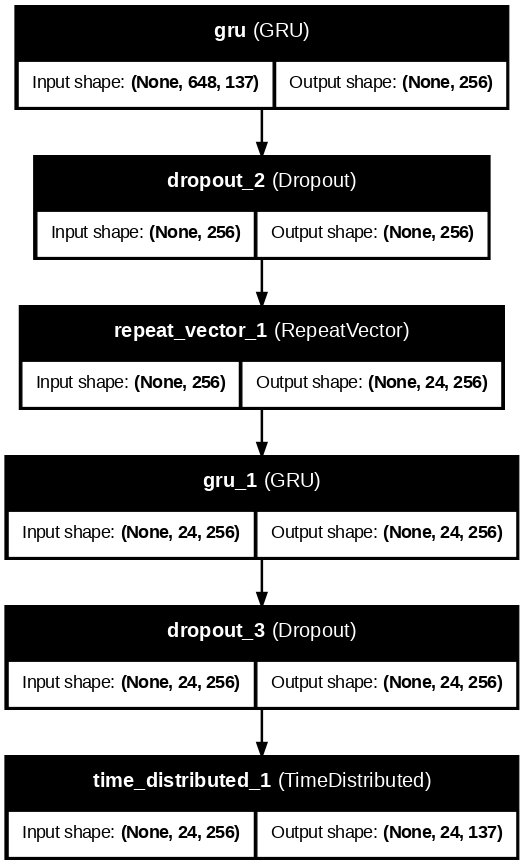

In [17]:
from keras.utils import plot_model

import os

d = "images/"
parent_d = "/kaggle/working/"
image_path = os.path.join(parent_d, d)

if not os.path.exists(image_path): 
    os.mkdir(image_path)
    print("Directory created at:", image_path)

plot_model(
    gru,
    to_file="/kaggle/working/images/gru.png",
    show_shapes=True,
    show_layer_names=True,
    expand_nested=True,
    dpi=90
)


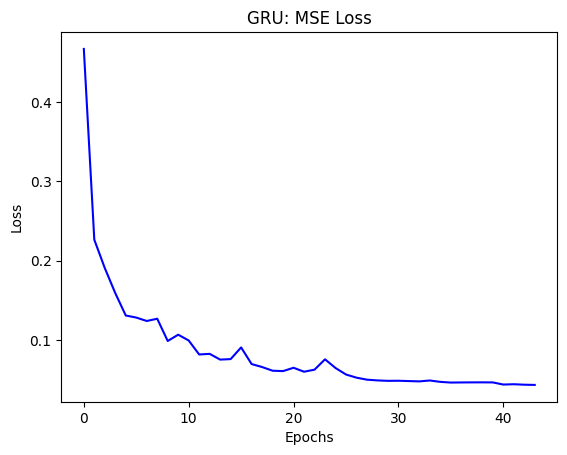

In [18]:
from matplotlib import pyplot as plt

n = len(loss["loss"])
# plt.figure(figsize=(4, 1))
# plt.legend()
plt.title("GRU: MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.plot(np.arange(n), loss["loss"], "b")

In [19]:
# Make predictions on the normalized test set
# The output shape will be (num_test_windows, HORIZON, NUM_LOCATIONS)
# (347, 24, 137) in your case
y_pred_n = gru.predict(X_test_n) 

y_pred = denormalize(scaler, y_pred_n)

print(f"Final Denormalized Predictions shape: {y_pred.shape}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step
Final Denormalized Predictions shape: (347, 24, 137)


In [20]:
print("GRU predictions:")
print()
print("Normalized:")
eva_regress(y_test_n, y_pred_n)

print()
print("Denomalized:")
eva_regress(y_test, y_pred)
print()

GRU predictions:

Normalized:
mae:0.356020
mse:0.385687
rmse:0.621037
r2:0.578714

Denomalized:
mae:31.228439
mse:2967.467150
rmse:54.474463
r2:0.578714



In [21]:
location_id = 5  # user input
predictions_for_location = y_pred[:, :, location_id]  # shape: (347, 24)
# Take the most recent window, or average across windows
final_prediction = predictions_for_location[-1, :]  # shape: (24,)
# This is: [flow_hour1, flow_hour2, ..., flow_hour24]
final_prediction

array([116.27276  , 104.47518  ,  88.4045   ,  76.86475  ,  67.954285 ,
        60.375202 ,  53.719032 ,  47.9062   ,  42.86213  ,  38.487392 ,
        34.688175 ,  31.386974 ,  28.520962 ,  26.037884 ,  23.892933 ,
        22.046589 ,  20.463352 ,  19.110943 ,  17.95995  ,  16.983791 ,
        16.159077 ,  15.466129 ,  14.8894615,  14.417789 ], dtype=float32)

In [22]:
windows[-1:].shape

(1, 672, 137)

In [23]:
scats = {}
for i, v in enumerate(flow.columns):
    z = v[:4]
    if scats.get(z) is None:
        scats[z] = [i]
    else:
        scats[z].append(i)
scats

{'0970': [0, 1, 2, 3],
 '2000': [4, 5, 6, 7],
 '2200': [8, 9, 10, 11],
 '2820': [12, 13],
 '2825': [14],
 '2827': [15, 16, 17, 18],
 '2846': [19, 20, 21, 22],
 '3001': [23, 24, 25],
 '3002': [26, 27, 28, 29],
 '3120': [30, 31, 32, 33],
 '3122': [34, 35, 36],
 '3126': [37, 38, 39],
 '3127': [40, 41, 42],
 '3180': [43, 44, 45],
 '3662': [46, 47, 48, 49],
 '3682': [50, 51, 52, 53],
 '3685': [54, 55, 56],
 '3804': [57, 58, 59, 60],
 '3812': [61, 62, 63, 64],
 '4030': [65, 66, 67],
 '4032': [68, 69, 70, 71],
 '4034': [72, 73, 74, 75],
 '4035': [76, 77, 78, 79],
 '4040': [80, 81, 82, 83, 84, 85],
 '4043': [86, 87, 88, 89],
 '4051': [90, 91, 92],
 '4057': [93, 94, 95, 96],
 '4063': [97, 98, 99, 100],
 '4262': [101],
 '4263': [102, 103, 104, 105],
 '4264': [106, 107, 108, 109],
 '4266': [110, 111, 112, 113],
 '4270': [114, 115, 116, 117],
 '4272': [118, 119, 120],
 '4273': [121, 122],
 '4321': [123, 124, 125, 126],
 '4324': [127, 128, 129],
 '4812': [130, 131, 132],
 '4821': [133, 134, 135, 13

In [24]:
from typing import Any
SCATS_TO_LOC = scats
def predict_future(model: Any, last_window: np.ndarray, scaler: StandardScaler, num_steps_ahead: int, step_size=24):
    """
    Predict future traffic values with normalization handled automatically.
    
    Args:
        model: Trained keras model.
        last_window: np.ndarray of shape (1, WINDOW_LENGTH, NUM_LOCATION)
        scaler: sklearn StandardScaler fitted on training data.
        num_steps_ahead: Total number of timesteps to predict.
        step_size: Number of timesteps to shift window each iteration.
    
    Returns:
        np.ndarray of shape (num_steps_ahead, NUM_LOCATION) with denormalized predictionsa.
    """
    # Normalize input
    current_window = normalize(scaler, last_window)
    all_predictions = []

    i = 0
    while len(all_predictions) < num_steps_ahead:
        i += 1
        pred_n = model.predict(current_window, verbose=0)  # normalized predictions
        all_predictions.append(pred_n[0])
        # print(f"Prediction #{i}: {pred_n[0]}")
        current_window = np.concatenate([
            current_window[:, step_size:, :],
            pred_n
        ], axis=1)

    predictions_n = np.vstack(all_predictions)[:num_steps_ahead]

    # Denormalize output
    predictions = denormalize(scaler, predictions_n)
    return predictions


def predict_interval(model: Any, last_window: np.ndarray, scaler: StandardScaler, 
                     scats_number: str, start_time_str: str, end_time_str: str) -> np.ndarray:
    """
    Predict for a given SCATS number and datetime interval.
    
    Args:
        model: trained keras model
        last_window: last observed window (1, WINDOW_LENGTH, NUM_LOCATION)
        scaler: fitted StandardScaler
        scats_number: str, e.g., '3002'
        start_time_str: 'YYYY-MM-DD HH:MM'
        end_time_str: 'YYYY-MM-DD HH:MM'
    
    Returns:
        np.ndarray of shape (num_steps_in_interval, num_locations_for_SCATS)
    """
    loc_indices = SCATS_TO_LOC.get(scats_number)
    if not loc_indices:
        raise ValueError("SCATS number not found!")

    start_time = pd.to_datetime(start_time_str)
    end_time = pd.to_datetime(end_time_str)
    # should predict from here
    ref_time = pd.Timestamp("2006-11-01 00:00")  # reference start

    start_step = int((start_time - ref_time) / pd.Timedelta(minutes=15))
    end_step = int((end_time - ref_time) / pd.Timedelta(minutes=15))

    total_steps_needed = end_step + 1

    # Predict
    predictions = predict_future(model, last_window, scaler, total_steps_needed)

    # Slice interval and select SCATS locations
    pred_interval = predictions[start_step:end_step + 1, loc_indices]
    # should be already flattened? Just to be sure.
    return np.array(np.median(pred_interval, axis=1)).flatten()


def predict_traffic(scats_number: str, start_time_str: str, end_time_str: str, model_choice="GRU"):
    try:
        start_time = pd.to_datetime(start_time_str)
        end_time = pd.to_datetime(end_time_str)
        if start_time.minute % 15 or end_time.minute % 15:
            raise ValueError("Timestamps must align to 15-minute intervals.")
        if start_time > end_time:
            raise ValueError("Start time must be before end time.")

        model = gru if model_choice == "GRU" else lstm
        last_window = normalize(scaler, windows[-1:])
        pred_interval = predict_interval(model, last_window, scaler, scats_number, start_time_str, end_time_str)

        timestamps = pd.date_range(start=start_time, end=end_time, freq="15min")
        if len(timestamps) != len(pred_interval):
            raise ValueError(f"Timestamp count {len(timestamps)} does not match prediction length {len(pred_interval)}.")

        text = (
            f"Predicted flow for SCATS {scats_number}\n"
            f"From {start_time} to {end_time}\n"
            f"{len(pred_interval)} intervals (15 min)\n\n"
            f"{pred_interval}"
        )

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(timestamps, pred_interval, marker="o")
        ax.set_title(f"Predicted Flow for SCATS {scats_number}")
        ax.set_xlabel("Time")
        ax.set_ylabel("Flow")
        ax.grid(True, alpha=0.3)
        fig.autofmt_xdate()

        return text, fig

    except Exception as e:
        return f"Error: {str(e)}", None

In [25]:
import gradio as gr
interface = gr.Interface(
    fn=predict_traffic,
    inputs=[
        gr.Textbox(label="SCATS Number", placeholder="3002"),
        gr.Textbox(label="Start Time", placeholder="2006-11-05 09:30"),
        gr.Textbox(label="End Time", placeholder="2006-11-05 11:30"),
        gr.Radio(["LSTM", "GRU"], label="Model", value="GRU")
    ],
    outputs=[
        gr.Textbox(label="Prediction Output"),
        gr.Plot(label="Flow Plot")
    ],
    title="Traffic Flow Prediction",
    description="Predict traffic flow for a given SCATS location and time interval")

interface.launch(share=True)

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://0f3fe22f0ce3cb8de1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
